In [89]:
#Cell 1: Libraries import
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [90]:
#Cell 2: Paths and settings
train_path = "dataset/train"
test_path = "dataset/test"

img_size = 128
batch_size = 32

In [91]:
# Cell 3: Image preprocessing

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=25,

    zoom_range=0.25,

    horizontal_flip=True,

    width_shift_range=0.2,

    height_shift_range=0.2,

    brightness_range=[0.8, 1.2]

)

test_datagen = ImageDataGenerator(

    rescale=1./255

)

In [92]:
# Cell 4: Dataset load

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)
print(train_data.class_indices)

Found 1339 images belonging to 11 classes.
Found 411 images belonging to 11 classes.
{'FreshApple': 0, 'FreshBanana': 1, 'FreshMango': 2, 'FreshPotato': 3, 'FreshTomato': 4, 'RottenApple': 5, 'RottenBanana': 6, 'RottenMango': 7, 'RottenPotato': 8, 'RottenTomato': 9, 'unknown': 10}


In [93]:
#Cell 5: Class names check
print(train_data.class_indices)

{'FreshApple': 0, 'FreshBanana': 1, 'FreshMango': 2, 'FreshPotato': 3, 'FreshTomato': 4, 'RottenApple': 5, 'RottenBanana': 6, 'RottenMango': 7, 'RottenPotato': 8, 'RottenTomato': 9, 'unknown': 10}


In [94]:
#Cell 6: CNN Model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(11, activation="softmax")
])

In [95]:
#Cell 7: Compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [96]:
#Cell 8: Model summary
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_6           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 11)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,371 (9.24 MB)

 Trainable params: 165,387 (646.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [97]:
#Cell 9: Train model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.5250 - loss: 1.4918 - val_accuracy: 0.7153 - val_loss: 0.8674
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7894 - loss: 0.6861 - val_accuracy: 0.8248 - val_loss: 0.5535
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8252 - loss: 0.5486 - val_accuracy: 0.8662 - val_loss: 0.4371
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8686 - loss: 0.4343 - val_accuracy: 0.8491 - val_loss: 0.4329
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8790 - loss: 0.3610 - val_accuracy: 0.8686 - val_loss: 0.3708
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8947 - loss: 0.3290 - val_accuracy: 0.8589 - val_loss: 0.3825
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8910 - loss: 0.3253 - val_accuracy: 0.8637 - val_loss: 0.3633
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9171 - loss: 0.2657 - val_accuracy: 0.8856 - val_loss:

In [98]:
#Cell 10: Save model
model.save("model/freshscan_model.h5")
print("Model saved successfully!")

Model saved successfully!


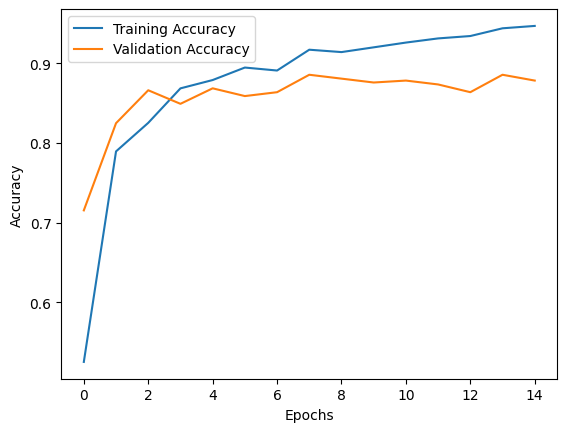

In [99]:
#Cell 11: Accuracy graph
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [100]:
print(train_data.class_indices)

{'FreshApple': 0, 'FreshBanana': 1, 'FreshMango': 2, 'FreshPotato': 3, 'FreshTomato': 4, 'RottenApple': 5, 'RottenBanana': 6, 'RottenMango': 7, 'RottenPotato': 8, 'RottenTomato': 9, 'unknown': 10}
